# Notebook 03: Projection and Splatting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase1/03_projection_splatting.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand pinhole camera models and intrinsic/extrinsic parameters
2. Learn how to project 3D points to 2D image coordinates
3. Derive and implement the projection Jacobian for covariance transformation
4. Master the "splatting" operation: projecting 3D Gaussians to 2D
5. Implement a complete 2D Gaussian splatting pipeline

**Estimated Time**: 75 minutes

**Prerequisites**: Notebook 02 (3D Gaussian Math)

---

## Setup

In [11]:
import os
import sys

# Colab setup
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('3DGS-from-scratch'):
        !git clone https://github.com/ChunLI-666/3DGS-from-scratch.git
    os.chdir('3DGS-from-scratch')
    !pip install -q plotly ipywidgets

# Path setup
for path in ['../../src', '../src', './src']:
    full_path = os.path.abspath(path)
    if os.path.exists(os.path.join(full_path, 'gaussian')):
        sys.path.insert(0, full_path)
        break

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("Setup complete!")

Using device: cuda
Setup complete!


## 1. Camera Models: From 3D to 2D

### The Pinhole Camera Model

The pinhole camera is a simple but powerful model for how cameras capture images.

```
World Point         Camera           Image Plane
    P(X,Y,Z)  -->  Transform  -->    p(u,v)
```

### Two-Step Process:

1. **Extrinsic Transformation**: World → Camera coordinates
   $$\mathbf{p}_{cam} = R \cdot \mathbf{p}_{world} + \mathbf{t}$$

2. **Intrinsic Projection**: Camera → Image coordinates
   $$u = f_x \cdot \frac{x}{z} + c_x$$
   $$v = f_y \cdot \frac{y}{z} + c_y$$

### Camera Parameters

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| Focal Length | $f_x, f_y$ | Distance to image plane (pixels) |
| Principal Point | $c_x, c_y$ | Image center offset |
| Rotation | $R$ | World to camera rotation [3×3] |
| Translation | $\mathbf{t}$ | Camera position [3] |

### Intrinsic Matrix $K$

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

In [12]:
from dataclasses import dataclass
from typing import Tuple, Optional

@dataclass
class Camera:
    """
    Pinhole camera model.
    
    Attributes:
        fx, fy: Focal lengths (pixels)
        cx, cy: Principal point
        width, height: Image dimensions
        R: Rotation matrix [3, 3] (world to camera)
        t: Translation vector [3] (world to camera)
    """
    fx: float
    fy: float
    cx: float
    cy: float
    width: int
    height: int
    R: torch.Tensor  # [3, 3] rotation
    t: torch.Tensor  # [3] translation
    
    @property
    def K(self) -> torch.Tensor:
        """Intrinsic matrix [3, 3]."""
        return torch.tensor([
            [self.fx, 0, self.cx],
            [0, self.fy, self.cy],
            [0, 0, 1]
        ], dtype=self.R.dtype, device=self.R.device)
    
    @property
    def extrinsic(self) -> torch.Tensor:
        """Extrinsic matrix [4, 4]."""
        T = torch.eye(4, dtype=self.R.dtype, device=self.R.device)
        T[:3, :3] = self.R
        T[:3, 3] = self.t
        return T
    
    def world_to_camera(self, point_world: torch.Tensor) -> torch.Tensor:
        """Transform point from world to camera coordinates."""
        return self.R @ point_world + self.t
    
    def project(self, point_world: torch.Tensor) -> torch.Tensor:
        """Project 3D world point to 2D image coordinates."""
        point_cam = self.world_to_camera(point_world)
        x, y, z = point_cam[0], point_cam[1], point_cam[2]
        u = self.fx * x / z + self.cx
        v = self.fy * y / z + self.cy
        return torch.stack([u, v]), z  # Return 2D point and depth


# Create a sample camera
camera = Camera(
    fx=500.0, fy=500.0,  # Focal length
    cx=320.0, cy=240.0,  # Image center (640x480 image)
    width=640, height=480,
    R=torch.eye(3),      # Identity rotation
    t=torch.tensor([0., 0., 0.])  # At origin
)

print("Camera Parameters:")
print(f"  Focal length: ({camera.fx}, {camera.fy})")
print(f"  Principal point: ({camera.cx}, {camera.cy})")
print(f"  Image size: {camera.width}x{camera.height}")
print(f"\nIntrinsic Matrix K:")
print(camera.K)

Camera Parameters:
  Focal length: (500.0, 500.0)
  Principal point: (320.0, 240.0)
  Image size: 640x480

Intrinsic Matrix K:
tensor([[500.,   0., 320.],
        [  0., 500., 240.],
        [  0.,   0.,   1.]])


In [13]:
# Project some 3D points
test_points = torch.tensor([
    [0., 0., 5.],     # On optical axis, 5m away
    [1., 0., 5.],     # 1m right
    [0., 1., 5.],     # 1m up
    [-1., -1., 5.],   # Left-down
    [0., 0., 10.],    # Same direction, further away
])

print("Point Projection:")
print("=" * 60)
print(f"{'3D Point (X,Y,Z)':^25} | {'2D Point (u,v)':^20} | {'Depth':^10}")
print("-" * 60)

projected_points = []
for point in test_points:
    uv, depth = camera.project(point)
    projected_points.append(uv.numpy())
    print(f"{str(point.numpy()):^25} | ({uv[0]:.1f}, {uv[1]:.1f}):^20 | {depth:.1f}")

print("\nObservations:")
print("- Point on optical axis projects to image center (cx, cy)")
print("- Moving right in 3D → moving right in image")
print("- Depth doesn't change 2D position if direction is same")
print("- But depth affects the SIZE of projected objects")

Point Projection:
    3D Point (X,Y,Z)      |    2D Point (u,v)    |   Depth   
------------------------------------------------------------
       [0. 0. 5.]         | (320.0, 240.0):^20 | 5.0
       [1. 0. 5.]         | (420.0, 240.0):^20 | 5.0
       [0. 1. 5.]         | (320.0, 340.0):^20 | 5.0
      [-1. -1.  5.]       | (220.0, 140.0):^20 | 5.0
      [ 0.  0. 10.]       | (320.0, 240.0):^20 | 10.0

Observations:
- Point on optical axis projects to image center (cx, cy)
- Moving right in 3D → moving right in image
- Depth doesn't change 2D position if direction is same
- But depth affects the SIZE of projected objects


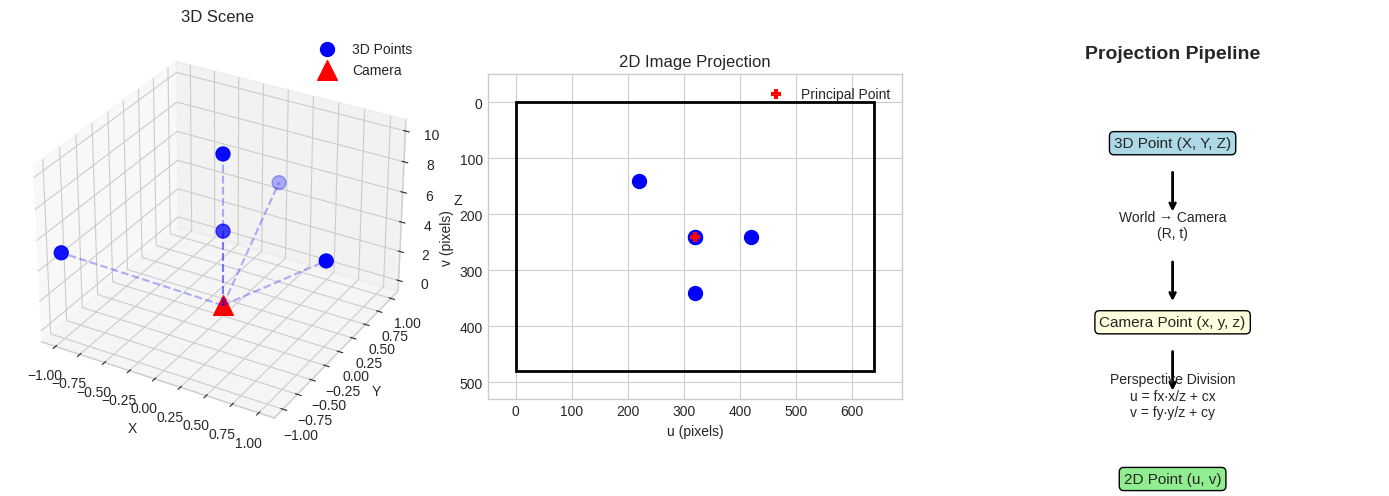

In [14]:
# Visualize projection
fig = plt.figure(figsize=(14, 5))

# 3D scene view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(test_points[:, 0], test_points[:, 1], test_points[:, 2], 
           c='blue', s=100, label='3D Points')
ax1.scatter(0, 0, 0, c='red', s=200, marker='^', label='Camera')

# Draw camera frustum
for point in test_points:
    ax1.plot([0, point[0]], [0, point[1]], [0, point[2]], 'b--', alpha=0.3)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Scene')
ax1.legend()

# 2D image view
ax2 = fig.add_subplot(132)
projected = np.array(projected_points)
ax2.scatter(projected[:, 0], projected[:, 1], c='blue', s=100)

# Draw image boundary
rect = plt.Rectangle((0, 0), camera.width, camera.height, 
                      fill=False, edgecolor='black', linewidth=2)
ax2.add_patch(rect)
ax2.scatter(camera.cx, camera.cy, c='red', s=50, marker='+', linewidths=3, label='Principal Point')

ax2.set_xlim(-50, camera.width + 50)
ax2.set_ylim(camera.height + 50, -50)  # Flip Y for image coordinates
ax2.set_xlabel('u (pixels)')
ax2.set_ylabel('v (pixels)')
ax2.set_title('2D Image Projection')
ax2.set_aspect('equal')
ax2.legend()

# Projection diagram
ax3 = fig.add_subplot(133)
ax3.text(0.5, 0.9, 'Projection Pipeline', ha='center', fontsize=14, fontweight='bold', transform=ax3.transAxes)
ax3.text(0.5, 0.7, '3D Point (X, Y, Z)', ha='center', fontsize=11, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue'))
ax3.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.65), transform=ax3.transAxes,
             arrowprops=dict(arrowstyle='->', lw=2))
ax3.text(0.5, 0.5, 'World → Camera\n(R, t)', ha='center', fontsize=10, transform=ax3.transAxes)
ax3.annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.45), transform=ax3.transAxes,
             arrowprops=dict(arrowstyle='->', lw=2))
ax3.text(0.5, 0.3, 'Camera Point (x, y, z)', ha='center', fontsize=11, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax3.annotate('', xy=(0.5, 0.15), xytext=(0.5, 0.25), transform=ax3.transAxes,
             arrowprops=dict(arrowstyle='->', lw=2))
ax3.text(0.5, 0.1, 'Perspective Division\nu = fx·x/z + cx\nv = fy·y/z + cy', 
         ha='center', fontsize=10, transform=ax3.transAxes)
ax3.text(0.5, -0.05, '2D Point (u, v)', ha='center', fontsize=11, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen'))
ax3.axis('off')

plt.tight_layout()
plt.show()

def quaternion_to_rotation_matrix(q):
    """Convert quaternion to rotation matrix."""
    q = q / torch.norm(q)
    w, x, y, z = q[0], q[1], q[2], q[3]
    
    R = torch.tensor([
        [1 - 2*(y*y + z*z),     2*(x*y - w*z),     2*(x*z + w*y)],
        [    2*(x*y + w*z), 1 - 2*(x*x + z*z),     2*(y*z - w*x)],
        [    2*(x*z - w*y),     2*(y*z + w*x), 1 - 2*(x*x + y*y)]
    ], dtype=q.dtype, device=q.device)
    
    return R


def build_covariance_from_params(scaling, rotation_quat):
    """Build 3D covariance from scaling and rotation."""
    R = quaternion_to_rotation_matrix(rotation_quat)
    S = torch.diag(scaling)
    return R @ S @ S.T @ R.T


# Create a 3D Gaussian
mean_3d = torch.tensor([0., 0., 5.], dtype=torch.float32)  # 5 meters in front
scaling = torch.tensor([0.5, 0.3, 0.2], dtype=torch.float32)  # Elongated ellipsoid
rotation = torch.tensor([1., 0., 0., 0.], dtype=torch.float32)  # No rotation

cov_3d = build_covariance_from_params(scaling, rotation)

print("3D Gaussian Parameters:")
print(f"  Mean: {mean_3d.tolist()}")
print(f"  Scaling: {scaling.tolist()}")
print(f"\n3D Covariance:")
print(cov_3d.numpy().round(3))

# Project to 2D
camera = Camera(fx=500, fy=500, cx=320, cy=240, width=640, height=480,
               R=torch.eye(3, dtype=torch.float32), t=torch.zeros(3, dtype=torch.float32))

mean_cam = camera.world_to_camera(mean_3d)
cov_2d = project_covariance_to_2d(cov_3d, mean_cam, camera)

print(f"\n2D Covariance:")
print(cov_2d.numpy().round(3))

# Compute 2D ellipse parameters
eigenvalues, eigenvectors = torch.linalg.eigh(cov_2d)
print(f"\n2D Eigenvalues: {eigenvalues.tolist()}")
print(f"2D Standard deviations: {torch.sqrt(eigenvalues).tolist()} pixels")

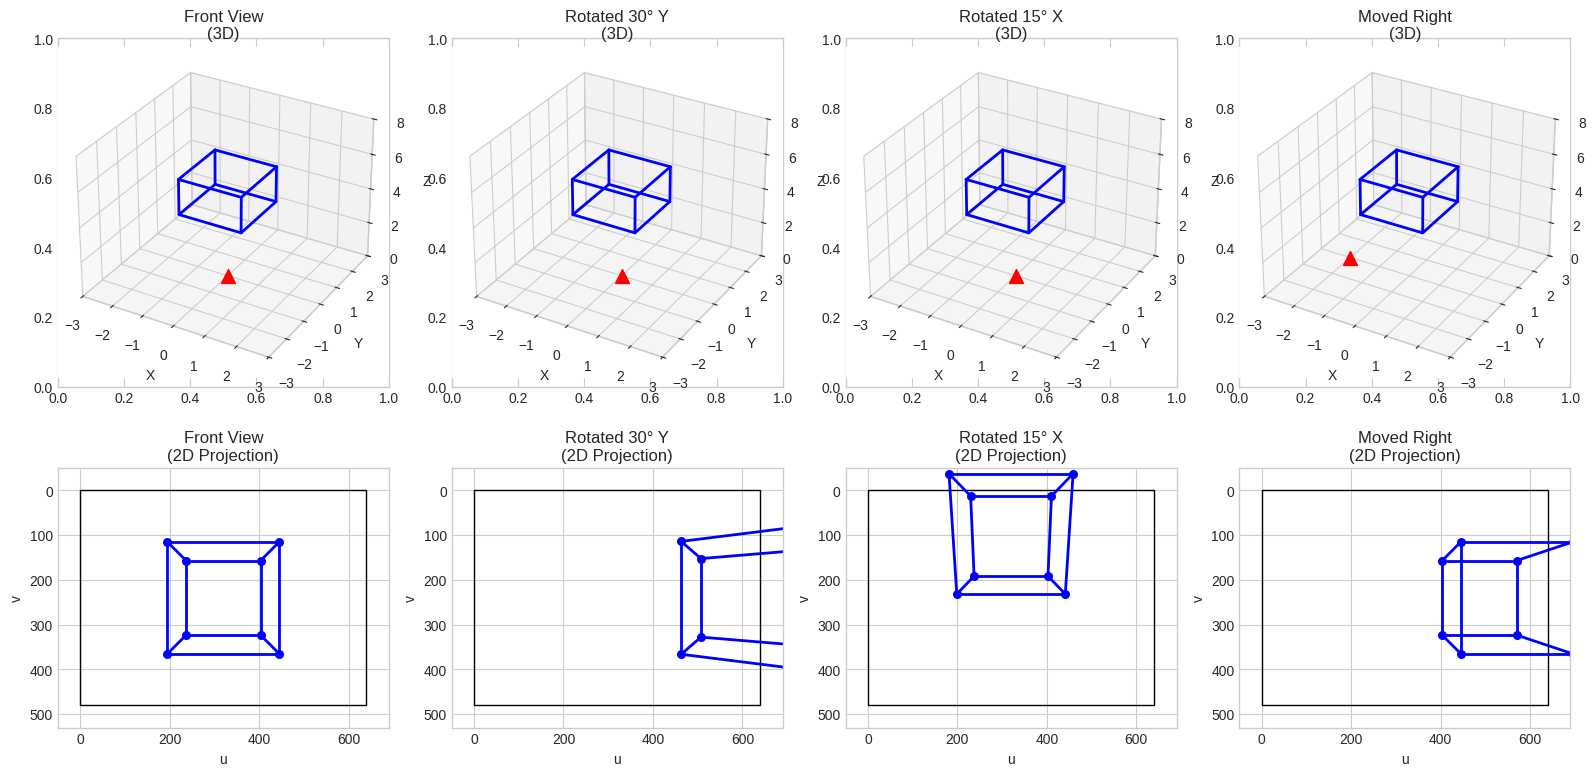

In [15]:
def rotation_matrix_y(angle_deg):
    """Create rotation matrix around Y axis."""
    theta = np.radians(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    return torch.tensor([
        [c, 0, s],
        [0, 1, 0],
        [-s, 0, c]
    ], dtype=torch.float32)

def rotation_matrix_x(angle_deg):
    """Create rotation matrix around X axis."""
    theta = np.radians(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    return torch.tensor([
        [1, 0, 0],
        [0, c, -s],
        [0, s, c]
    ], dtype=torch.float32)

# Create a scene with a cube
def create_cube(center, size):
    """Create 8 corners of a cube."""
    half = size / 2
    corners = torch.tensor([
        [-half, -half, -half],
        [half, -half, -half],
        [half, half, -half],
        [-half, half, -half],
        [-half, -half, half],
        [half, -half, half],
        [half, half, half],
        [-half, half, half],
    ], dtype=torch.float32)
    return corners + center

# Cube edges (pairs of vertex indices)
edges = [(0,1), (1,2), (2,3), (3,0),  # Front face
         (4,5), (5,6), (6,7), (7,4),  # Back face
         (0,4), (1,5), (2,6), (3,7)]  # Connecting edges

# Create cube at z=5
cube_corners = create_cube(torch.tensor([0., 0., 5.]), 2.0)

# Different camera poses
camera_poses = [
    ("Front View", torch.eye(3), torch.tensor([0., 0., 0.])),
    ("Rotated 30° Y", rotation_matrix_y(30), torch.tensor([0., 0., 0.])),
    ("Rotated 15° X", rotation_matrix_x(15), torch.tensor([0., 0., 0.])),
    ("Moved Right", torch.eye(3), torch.tensor([2., 0., 0.])),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, R, t) in enumerate(camera_poses):
    cam = Camera(
        fx=500, fy=500, cx=320, cy=240,
        width=640, height=480,
        R=R, t=t
    )
    
    # Project cube corners
    projected = []
    for corner in cube_corners:
        uv, depth = cam.project(corner)
        projected.append(uv.numpy())
    projected = np.array(projected)
    
    # Top row: 3D view
    ax3d = fig.add_subplot(2, 4, i+1, projection='3d')
    for e in edges:
        pts = cube_corners[[e[0], e[1]]].numpy()
        ax3d.plot(pts[:, 0], pts[:, 1], pts[:, 2], 'b-', linewidth=2)
    
    # Draw camera
    cam_pos = -R.T @ t  # Camera position in world
    ax3d.scatter(*cam_pos.numpy(), c='red', s=100, marker='^')
    
    ax3d.set_xlim(-3, 3)
    ax3d.set_ylim(-3, 3)
    ax3d.set_zlim(0, 8)
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title(f'{name}\n(3D)')
    
    # Bottom row: 2D projection
    ax2d = axes[1, i]
    for e in edges:
        ax2d.plot(projected[[e[0], e[1]], 0], projected[[e[0], e[1]], 1], 'b-', linewidth=2)
    ax2d.scatter(projected[:, 0], projected[:, 1], c='blue', s=30)
    
    rect = plt.Rectangle((0, 0), cam.width, cam.height, fill=False, edgecolor='black', linewidth=1)
    ax2d.add_patch(rect)
    
    ax2d.set_xlim(-50, cam.width + 50)
    ax2d.set_ylim(cam.height + 50, -50)
    ax2d.set_aspect('equal')
    ax2d.set_title(f'{name}\n(2D Projection)')
    ax2d.set_xlabel('u')
    ax2d.set_ylabel('v')

plt.tight_layout()
plt.show()

## 3. The Projection Jacobian

### Why We Need the Jacobian

When projecting a 3D Gaussian to 2D, we need to transform its covariance matrix. Since projection is nonlinear, we use a **local linear approximation** via the Jacobian.

### The Projection Function

$$\pi: \mathbb{R}^3 \rightarrow \mathbb{R}^2$$

$$\begin{aligned}
u &= f_x \cdot \frac{x}{z} + c_x \\
v &= f_y \cdot \frac{y}{z} + c_y
\end{aligned}$$

### The Jacobian Matrix

$$J = \frac{\partial \pi}{\partial \mathbf{p}} = \begin{bmatrix}
\frac{\partial u}{\partial x} & \frac{\partial u}{\partial y} & \frac{\partial u}{\partial z} \\
\frac{\partial v}{\partial x} & \frac{\partial v}{\partial y} & \frac{\partial v}{\partial z}
\end{bmatrix}$$

Computing the partial derivatives:

$$J = \begin{bmatrix}
\frac{f_x}{z} & 0 & -\frac{f_x \cdot x}{z^2} \\
0 & \frac{f_y}{z} & -\frac{f_y \cdot y}{z^2}
\end{bmatrix}$$

In [16]:
def compute_projection_jacobian(point_cam, fx, fy):
    """
    Compute the Jacobian of the projection function.
    
    Args:
        point_cam: Point in camera coordinates [3] or [N, 3]
        fx, fy: Focal lengths
    
    Returns:
        Jacobian matrix [2, 3] or [N, 2, 3]
    """
    if point_cam.dim() == 1:
        point_cam = point_cam.unsqueeze(0)
        squeeze = True
    else:
        squeeze = False
    
    x, y, z = point_cam[:, 0], point_cam[:, 1], point_cam[:, 2]
    z_sq = z * z
    
    batch_size = point_cam.shape[0]
    J = torch.zeros(batch_size, 2, 3, dtype=point_cam.dtype, device=point_cam.device)
    
    J[:, 0, 0] = fx / z           # du/dx
    J[:, 0, 2] = -fx * x / z_sq   # du/dz
    J[:, 1, 1] = fy / z           # dv/dy
    J[:, 1, 2] = -fy * y / z_sq   # dv/dz
    
    if squeeze:
        J = J.squeeze(0)
    
    return J


# Example: compute Jacobian at different depths
print("Projection Jacobian Examples:")
print("=" * 60)

test_points = [
    torch.tensor([0., 0., 5.]),   # On axis, z=5
    torch.tensor([0., 0., 10.]),  # On axis, z=10
    torch.tensor([2., 1., 5.]),   # Off axis, z=5
]

fx, fy = 500.0, 500.0

for point in test_points:
    J = compute_projection_jacobian(point, fx, fy)
    print(f"\nPoint (camera): {point.tolist()}")
    print(f"Jacobian J:")
    print(J.numpy().round(3))
    print(f"  du/dx = fx/z = {fx/point[2]:.1f}")
    print(f"  du/dz = -fx*x/z² = {-fx*point[0]/(point[2]**2):.1f}")

Projection Jacobian Examples:

Point (camera): [0.0, 0.0, 5.0]
Jacobian J:
[[100.   0.  -0.]
 [  0. 100.  -0.]]
  du/dx = fx/z = 100.0
  du/dz = -fx*x/z² = -0.0

Point (camera): [0.0, 0.0, 10.0]
Jacobian J:
[[50.  0. -0.]
 [ 0. 50. -0.]]
  du/dx = fx/z = 50.0
  du/dz = -fx*x/z² = -0.0

Point (camera): [2.0, 1.0, 5.0]
Jacobian J:
[[100.   0. -40.]
 [  0. 100. -20.]]
  du/dx = fx/z = 100.0
  du/dz = -fx*x/z² = -40.0


### Intuition: What Does the Jacobian Tell Us?

1. **du/dx = fx/z**: Moving in X affects u, scaled by depth
   - Closer objects (small z) → larger change in image
   
2. **du/dz = -fx·x/z²**: Moving in Z affects u if off-axis
   - Moving closer makes off-axis points move away from center
   
3. **Depth scaling**: All terms have z in denominator
   - Closer = larger apparent motion

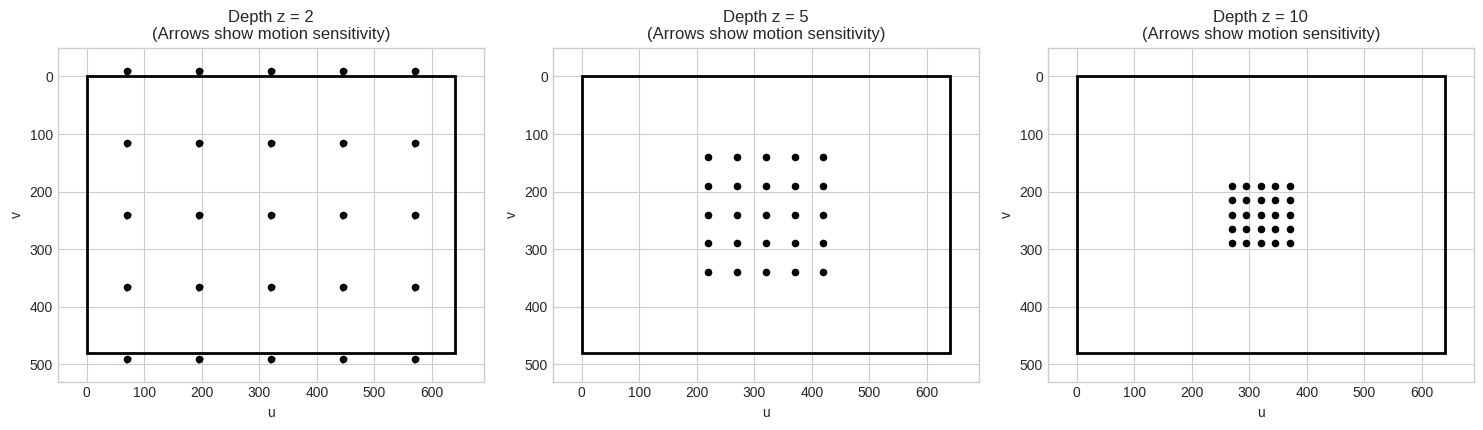

Red arrows: sensitivity to X motion
Blue arrows: sensitivity to Y motion
Note: Closer objects (smaller z) → larger arrows → more sensitive


In [17]:
# Visualize Jacobian effect: motion magnification at different depths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

depths = [2, 5, 10]

for ax, z in zip(axes, depths):
    # Create a grid of camera points
    x = np.linspace(-1, 1, 5)
    y = np.linspace(-1, 1, 5)
    X, Y = np.meshgrid(x, y)
    
    # Project to image
    U = fx * X / z + 320
    V = fy * Y / z + 240
    
    # Compute Jacobian magnitude at each point
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = torch.tensor([X[i,j], Y[i,j], float(z)])
            J = compute_projection_jacobian(point, fx, fy)
            
            # Draw Jacobian as vectors
            # Show du/dx and dv/dy as arrows
            scale = 0.02  # Scale for visualization
            ax.arrow(U[i,j], V[i,j], J[0,0].item()*scale, 0, 
                    head_width=5, head_length=3, fc='red', ec='red', alpha=0.7)
            ax.arrow(U[i,j], V[i,j], 0, J[1,1].item()*scale, 
                    head_width=5, head_length=3, fc='blue', ec='blue', alpha=0.7)
    
    ax.scatter(U.flatten(), V.flatten(), c='black', s=20, zorder=5)
    
    # Image boundary
    rect = plt.Rectangle((0, 0), 640, 480, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    ax.set_xlim(-50, 690)
    ax.set_ylim(530, -50)
    ax.set_aspect('equal')
    ax.set_title(f'Depth z = {z}\n(Arrows show motion sensitivity)')
    ax.set_xlabel('u')
    ax.set_ylabel('v')

plt.tight_layout()
plt.show()

print("Red arrows: sensitivity to X motion")
print("Blue arrows: sensitivity to Y motion")
print("Note: Closer objects (smaller z) → larger arrows → more sensitive")

## 4. Projecting 3D Gaussian Covariance to 2D

### The Splatting Formula

Given a 3D Gaussian with covariance $\Sigma_{3D}$, we project it to 2D as follows:

**Step 1: Transform to camera space**
$$\Sigma_{cam} = R \cdot \Sigma_{3D} \cdot R^T$$

**Step 2: Apply projection Jacobian**
$$\Sigma_{2D} = J \cdot \Sigma_{cam} \cdot J^T$$

Where $J$ is the [2×3] projection Jacobian.

### Why This Works

This is a **first-order Taylor approximation** of the nonlinear projection.

For a nonlinear function $f$ with Jacobian $J$:
$$\text{Cov}(f(x)) \approx J \cdot \text{Cov}(x) \cdot J^T$$

In [18]:
def project_covariance_to_2d(cov_3d, mean_cam, camera):
    """
    Project 3D covariance to 2D image space.
    
    Args:
        cov_3d: 3D covariance in world space [3, 3]
        mean_cam: Gaussian center in camera space [3]
        camera: Camera parameters
    
    Returns:
        2D covariance [2, 2]
    """
    # Step 1: Transform covariance to camera space
    cov_cam = camera.R @ cov_3d @ camera.R.T
    
    # Step 2: Compute projection Jacobian
    J = compute_projection_jacobian(mean_cam, camera.fx, camera.fy)
    
    # Step 3: Project to 2D
    cov_2d = J @ cov_cam @ J.T
    
    # Add small value for numerical stability
    cov_2d = cov_2d + torch.eye(2, dtype=cov_2d.dtype, device=cov_2d.device) * 0.3
    
    return cov_2d


# Example: Project a 3D Gaussian
def quaternion_to_rotation_matrix(q):
    """Convert quaternion to rotation matrix."""
    q = q / torch.norm(q)
    w, x, y, z = q[0], q[1], q[2], q[3]
    
    R = torch.tensor([
        [1 - 2*(y*y + z*z),     2*(x*y - w*z),     2*(x*z + w*y)],
        [    2*(x*y + w*z), 1 - 2*(x*x + z*z),     2*(y*z - w*x)],
        [    2*(x*z - w*y),     2*(y*z + w*x), 1 - 2*(x*x + y*y)]
    ], dtype=q.dtype, device=q.device)
    
    return R


def build_covariance_from_params(scaling, rotation_quat):
    """Build 3D covariance from scaling and rotation."""
    R = quaternion_to_rotation_matrix(rotation_quat)
    S = torch.diag(scaling)
    return R @ S @ S.T @ R.T


# Create a 3D Gaussian
mean_3d = torch.tensor([0., 0., 5.], dtype=torch.float32)  # 5 meters in front
scaling = torch.tensor([0.5, 0.3, 0.2], dtype=torch.float32)  # Elongated ellipsoid
rotation = torch.tensor([1., 0., 0., 0.], dtype=torch.float32)  # No rotation

cov_3d = build_covariance_from_params(scaling, rotation)

print("3D Gaussian Parameters:")
print(f"  Mean: {mean_3d.tolist()}")
print(f"  Scaling: {scaling.tolist()}")
print(f"\n3D Covariance:")
print(cov_3d.numpy().round(3))

# Project to 2D
camera = Camera(fx=500, fy=500, cx=320, cy=240, width=640, height=480,
               R=torch.eye(3, dtype=torch.float32), t=torch.zeros(3, dtype=torch.float32))

mean_cam = camera.world_to_camera(mean_3d)
cov_2d = project_covariance_to_2d(cov_3d, mean_cam, camera)

print(f"\n2D Covariance:")
print(cov_2d.numpy().round(3))

# Compute 2D ellipse parameters
eigenvalues, eigenvectors = torch.linalg.eigh(cov_2d)
print(f"\n2D Eigenvalues: {eigenvalues.tolist()}")
print(f"2D Standard deviations: {torch.sqrt(eigenvalues).tolist()} pixels")

3D Gaussian Parameters:
  Mean: [0.0, 0.0, 5.0]
  Scaling: [0.5, 0.30000001192092896, 0.20000000298023224]

3D Covariance:
[[0.25 0.   0.  ]
 [0.   0.09 0.  ]
 [0.   0.   0.04]]

2D Covariance:
[[2500.3    0. ]
 [   0.   900.3]]

2D Eigenvalues: [900.2999877929688, 2500.300048828125]
2D Standard deviations: [30.0049991607666, 50.00300216674805] pixels


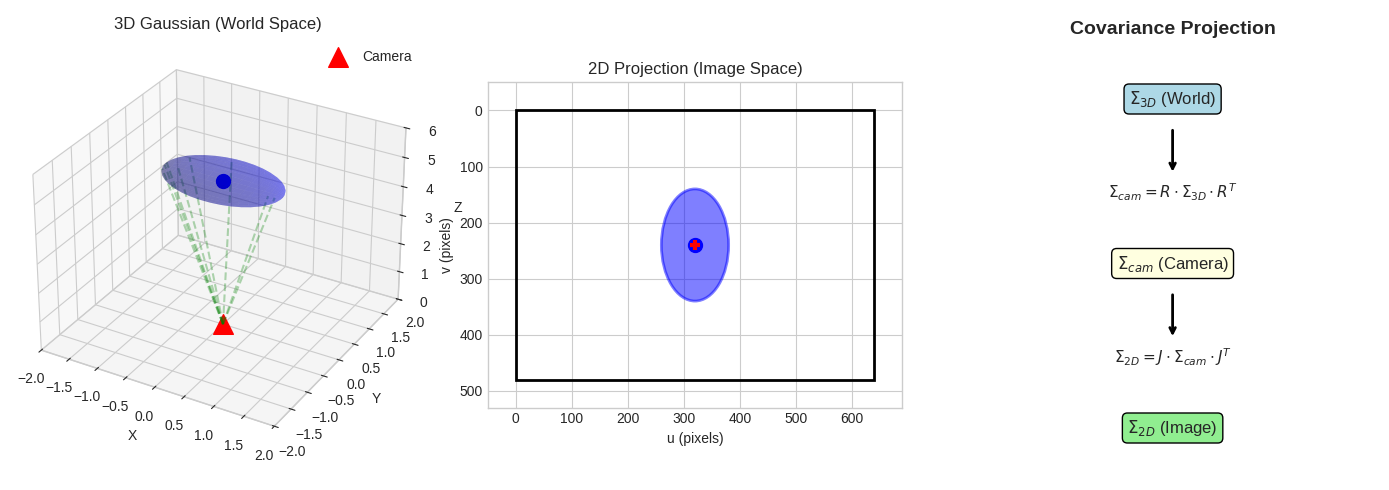

In [19]:
# Visualize 3D to 2D projection
fig = plt.figure(figsize=(14, 5))

# Helper: draw 3D ellipsoid
def plot_3d_ellipsoid(ax, mean, cov, color='blue', alpha=0.3, n_std=2):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    radii = n_std * np.sqrt(eigenvalues)
    
    # Create sphere
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    
    # Transform to ellipsoid
    sphere = np.stack([x, y, z], axis=-1)
    ellipsoid = np.einsum('ij,klj->kli', eigenvectors @ np.diag(radii), sphere) + mean
    
    ax.plot_surface(ellipsoid[:,:,0], ellipsoid[:,:,1], ellipsoid[:,:,2],
                   color=color, alpha=alpha)

# Helper: draw 2D ellipse
def plot_2d_ellipse(ax, mean, cov, color='blue', alpha=0.5, n_std=2):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    from matplotlib.patches import Ellipse
    ellipse = Ellipse(mean, width, height, angle=angle, 
                      facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    ax.add_patch(ellipse)

# 3D view
ax1 = fig.add_subplot(131, projection='3d')
plot_3d_ellipsoid(ax1, mean_3d.numpy(), cov_3d.numpy(), color='blue')
ax1.scatter(*mean_3d.numpy(), c='blue', s=100)
ax1.scatter(0, 0, 0, c='red', s=200, marker='^', label='Camera')

# Draw projection lines
for _ in range(8):
    theta = np.random.random() * 2 * np.pi
    phi = np.random.random() * np.pi
    eigvals, eigvecs = np.linalg.eigh(cov_3d.numpy())
    radii = 2 * np.sqrt(eigvals)
    offset = eigvecs @ (radii * np.array([np.sin(phi)*np.cos(theta), 
                                          np.sin(phi)*np.sin(theta), 
                                          np.cos(phi)]))
    point = mean_3d.numpy() + offset
    ax1.plot([0, point[0]], [0, point[1]], [0, point[2]], 'g--', alpha=0.3)

ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_zlim(0, 6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Gaussian (World Space)')
ax1.legend()

# 2D projection
ax2 = fig.add_subplot(132)
mean_2d, _ = camera.project(mean_3d)
plot_2d_ellipse(ax2, mean_2d.numpy(), cov_2d.numpy(), color='blue')
ax2.scatter(*mean_2d.numpy(), c='blue', s=100)

rect = plt.Rectangle((0, 0), 640, 480, fill=False, edgecolor='black', linewidth=2)
ax2.add_patch(rect)
ax2.scatter(320, 240, c='red', s=50, marker='+', linewidths=3)

ax2.set_xlim(-50, 690)
ax2.set_ylim(530, -50)
ax2.set_aspect('equal')
ax2.set_xlabel('u (pixels)')
ax2.set_ylabel('v (pixels)')
ax2.set_title('2D Projection (Image Space)')

# Formula diagram
ax3 = fig.add_subplot(133)
ax3.text(0.5, 0.95, 'Covariance Projection', ha='center', fontsize=14, fontweight='bold', transform=ax3.transAxes)

ax3.text(0.5, 0.8, r'$\Sigma_{3D}$ (World)', ha='center', fontsize=12, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue'))
ax3.annotate('', xy=(0.5, 0.65), xytext=(0.5, 0.75), transform=ax3.transAxes,
             arrowprops=dict(arrowstyle='->', lw=2))
ax3.text(0.5, 0.6, r'$\Sigma_{cam} = R \cdot \Sigma_{3D} \cdot R^T$', ha='center', fontsize=11, transform=ax3.transAxes)

ax3.text(0.5, 0.45, r'$\Sigma_{cam}$ (Camera)', ha='center', fontsize=12, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax3.annotate('', xy=(0.5, 0.3), xytext=(0.5, 0.4), transform=ax3.transAxes,
             arrowprops=dict(arrowstyle='->', lw=2))
ax3.text(0.5, 0.25, r'$\Sigma_{2D} = J \cdot \Sigma_{cam} \cdot J^T$', ha='center', fontsize=11, transform=ax3.transAxes)

ax3.text(0.5, 0.1, r'$\Sigma_{2D}$ (Image)', ha='center', fontsize=12, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen'))

ax3.axis('off')

plt.tight_layout()
plt.show()

## 5. Complete Splatting Pipeline

Now let's implement the complete splatting operation that projects a 3D Gaussian and evaluates it on an image grid.

In [20]:
@dataclass
class Gaussian3D:
    """A 3D Gaussian primitive."""
    mean: torch.Tensor      # [3]
    scaling: torch.Tensor   # [3]
    rotation: torch.Tensor  # [4] quaternion
    opacity: float
    color: torch.Tensor     # [3] RGB
    
    def get_covariance(self) -> torch.Tensor:
        return build_covariance_from_params(self.scaling, self.rotation)


@dataclass
class Gaussian2D:
    """A projected 2D Gaussian."""
    mean: torch.Tensor       # [2] image coords
    covariance: torch.Tensor # [2, 2]
    depth: float
    opacity: float
    color: torch.Tensor      # [3] RGB


def project_gaussian_to_2d(gaussian: Gaussian3D, camera: Camera) -> Optional[Gaussian2D]:
    """
    Project a 3D Gaussian to 2D image space.
    
    Returns None if the Gaussian is behind the camera or outside the image.
    """
    # Transform center to camera space
    mean_cam = camera.world_to_camera(gaussian.mean)
    
    # Skip if behind camera
    if mean_cam[2] <= 0.1:
        return None
    
    # Project center to image
    mean_2d, depth = camera.project(gaussian.mean)
    
    # Skip if outside image (with margin)
    margin = 100
    if (mean_2d[0] < -margin or mean_2d[0] > camera.width + margin or
        mean_2d[1] < -margin or mean_2d[1] > camera.height + margin):
        return None
    
    # Project covariance
    cov_3d = gaussian.get_covariance()
    cov_2d = project_covariance_to_2d(cov_3d, mean_cam, camera)
    
    return Gaussian2D(
        mean=mean_2d,
        covariance=cov_2d,
        depth=depth.item(),
        opacity=gaussian.opacity,
        color=gaussian.color
    )


def evaluate_gaussian_2d(gaussian: Gaussian2D, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Evaluate 2D Gaussian at given coordinates.
    
    Args:
        gaussian: Gaussian2D to evaluate
        x, y: Coordinate grids
    
    Returns:
        Gaussian values (0 to 1)
    """
    # Inverse covariance
    cov_inv = torch.linalg.inv(gaussian.covariance)
    
    # Offset from mean
    dx = x - gaussian.mean[0]
    dy = y - gaussian.mean[1]
    
    # Mahalanobis distance
    mahal = (cov_inv[0, 0] * dx * dx + 
             (cov_inv[0, 1] + cov_inv[1, 0]) * dx * dy + 
             cov_inv[1, 1] * dy * dy)
    
    return torch.exp(-0.5 * mahal)


# Create some 3D Gaussians
gaussians_3d = [
    Gaussian3D(
        mean=torch.tensor([0., 0., 5.], dtype=torch.float32),
        scaling=torch.tensor([0.5, 0.3, 0.2], dtype=torch.float32),
        rotation=torch.tensor([1., 0., 0., 0.], dtype=torch.float32),
        opacity=0.9,
        color=torch.tensor([1., 0., 0.], dtype=torch.float32)  # Red
    ),
    Gaussian3D(
        mean=torch.tensor([1., 0.5, 7.], dtype=torch.float32),
        scaling=torch.tensor([0.4, 0.4, 0.4], dtype=torch.float32),
        rotation=torch.tensor([1., 0., 0., 0.], dtype=torch.float32),
        opacity=0.8,
        color=torch.tensor([0., 1., 0.], dtype=torch.float32)  # Green
    ),
    Gaussian3D(
        mean=torch.tensor([-0.8, -0.3, 4.], dtype=torch.float32),
        scaling=torch.tensor([0.3, 0.5, 0.2], dtype=torch.float32),
        rotation=torch.tensor([np.cos(np.pi/8), 0., 0., np.sin(np.pi/8)], dtype=torch.float32),
        opacity=0.85,
        color=torch.tensor([0., 0., 1.], dtype=torch.float32)  # Blue
    ),
]

# Project all Gaussians
camera = Camera(fx=500, fy=500, cx=320, cy=240, width=640, height=480,
               R=torch.eye(3, dtype=torch.float32), t=torch.zeros(3, dtype=torch.float32))

gaussians_2d = []
for g3d in gaussians_3d:
    g2d = project_gaussian_to_2d(g3d, camera)
    if g2d is not None:
        gaussians_2d.append(g2d)

print(f"Projected {len(gaussians_2d)} out of {len(gaussians_3d)} Gaussians")

for i, g in enumerate(gaussians_2d):
    print(f"\nGaussian {i+1}:")
    print(f"  2D Mean: ({g.mean[0]:.1f}, {g.mean[1]:.1f})")
    print(f"  Depth: {g.depth:.2f}")
    print(f"  Color: {g.color.tolist()}")

Projected 3 out of 3 Gaussians

Gaussian 1:
  2D Mean: (320.0, 240.0)
  Depth: 5.00
  Color: [1.0, 0.0, 0.0]

Gaussian 2:
  2D Mean: (391.4, 275.7)
  Depth: 7.00
  Color: [0.0, 1.0, 0.0]

Gaussian 3:
  2D Mean: (220.0, 202.5)
  Depth: 4.00
  Color: [0.0, 0.0, 1.0]


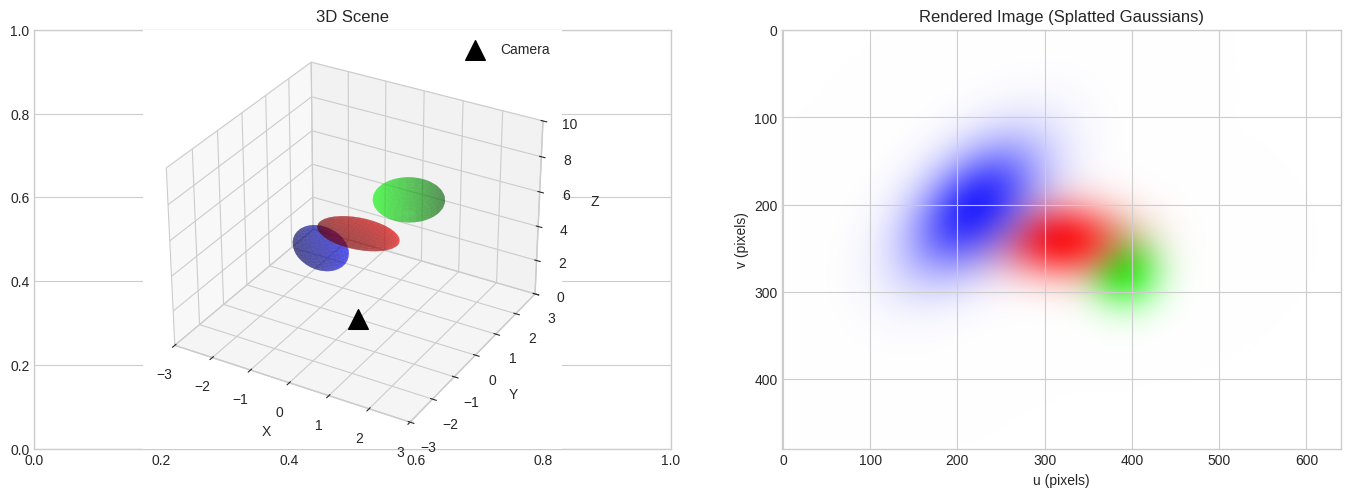

In [21]:
# Render the splatted Gaussians
def render_gaussians(gaussians_2d, camera, background=torch.tensor([1., 1., 1.])):
    """
    Render 2D Gaussians to an image.
    
    Uses simple additive blending (no proper alpha compositing yet).
    """
    H, W = camera.height, camera.width
    
    # Create coordinate grid
    y_coords, x_coords = torch.meshgrid(
        torch.arange(H, dtype=torch.float32),
        torch.arange(W, dtype=torch.float32),
        indexing='ij'
    )
    
    # Initialize image
    image = torch.zeros(H, W, 3)
    total_alpha = torch.zeros(H, W)
    
    # Sort by depth (front to back)
    sorted_gaussians = sorted(gaussians_2d, key=lambda g: g.depth)
    
    for g in sorted_gaussians:
        # Evaluate Gaussian
        gaussian_values = evaluate_gaussian_2d(g, x_coords, y_coords)
        alpha = gaussian_values * g.opacity
        
        # Simple alpha blending
        for c in range(3):
            image[:, :, c] += alpha * g.color[c] * (1 - total_alpha)
        total_alpha = total_alpha + alpha * (1 - total_alpha)
    
    # Add background
    for c in range(3):
        image[:, :, c] += background[c] * (1 - total_alpha)
    
    return torch.clamp(image, 0, 1)


# Render
image = render_gaussians(gaussians_2d, camera)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3D view
ax = fig.add_subplot(121, projection='3d')
for g in gaussians_3d:
    plot_3d_ellipsoid(ax, g.mean.numpy(), g.get_covariance().numpy(), 
                     color=g.color.numpy(), alpha=g.opacity * 0.5)
ax.scatter(0, 0, 0, c='black', s=200, marker='^', label='Camera')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scene')
ax.legend()

# Rendered image
axes[1].imshow(image.numpy())
axes[1].set_title('Rendered Image (Splatted Gaussians)')
axes[1].set_xlabel('u (pixels)')
axes[1].set_ylabel('v (pixels)')

plt.tight_layout()
plt.show()

## 6. Effect of Camera Movement

Let's see how the Gaussians look from different viewpoints.

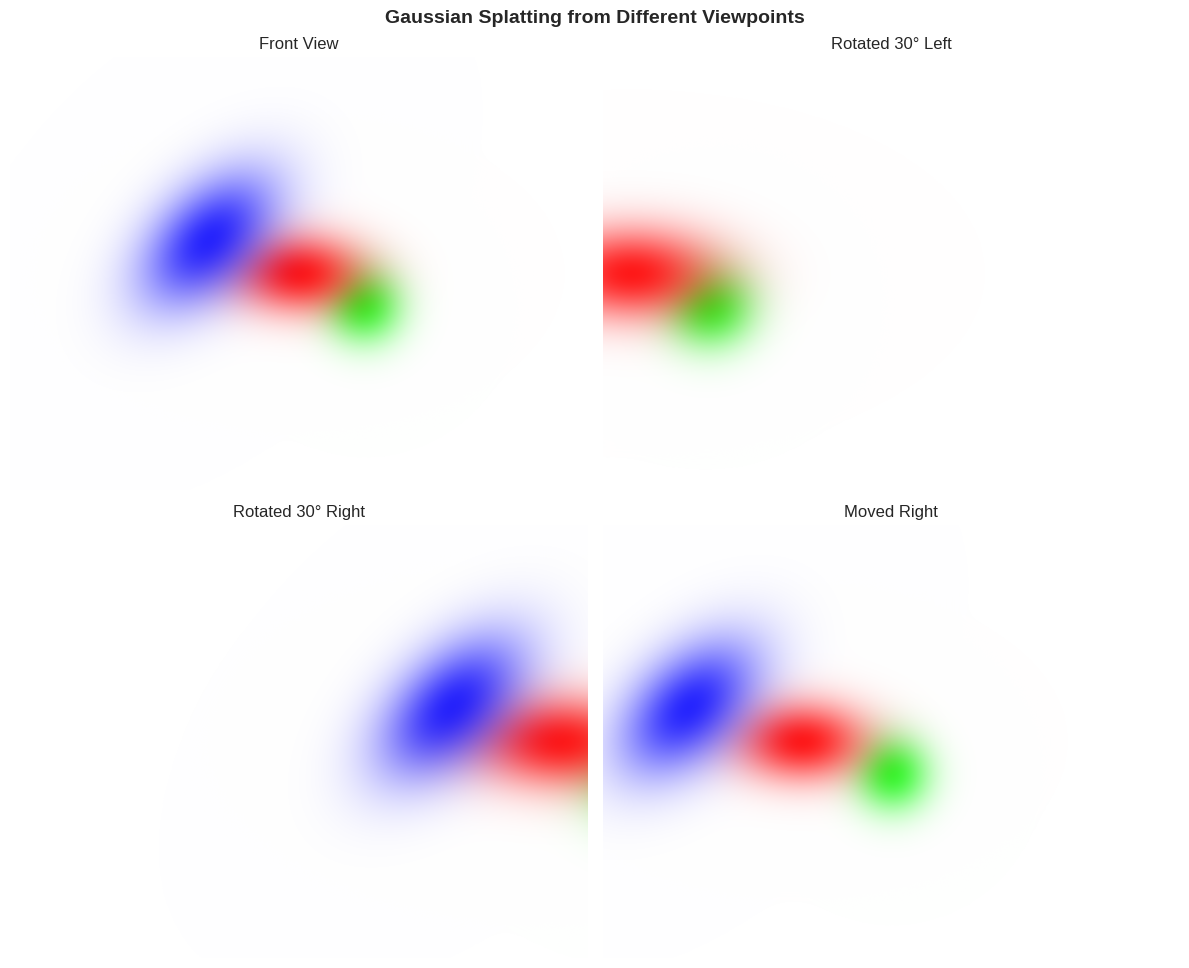

In [22]:
# Render from different camera poses
def rotation_matrix_y_torch(angle_deg):
    theta = torch.tensor(np.radians(angle_deg))
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.tensor([
        [c, 0, s],
        [0, 1, 0],
        [-s, 0, c]
    ], dtype=torch.float32)

camera_configs = [
    ("Front View", torch.eye(3), torch.zeros(3)),
    ("Rotated 30° Left", rotation_matrix_y_torch(-30), torch.zeros(3)),
    ("Rotated 30° Right", rotation_matrix_y_torch(30), torch.zeros(3)),
    ("Moved Right", torch.eye(3), torch.tensor([-1., 0., 0.])),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, R, t) in zip(axes.flat, camera_configs):
    cam = Camera(fx=500, fy=500, cx=320, cy=240, width=640, height=480, R=R, t=t)
    
    # Project Gaussians
    g2d_list = []
    for g3d in gaussians_3d:
        g2d = project_gaussian_to_2d(g3d, cam)
        if g2d is not None:
            g2d_list.append(g2d)
    
    # Render
    img = render_gaussians(g2d_list, cam)
    
    ax.imshow(img.numpy())
    ax.set_title(name)
    ax.axis('off')

plt.suptitle('Gaussian Splatting from Different Viewpoints', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Effect of Depth on Splat Size

A key property: Gaussians at different depths project to different sizes.

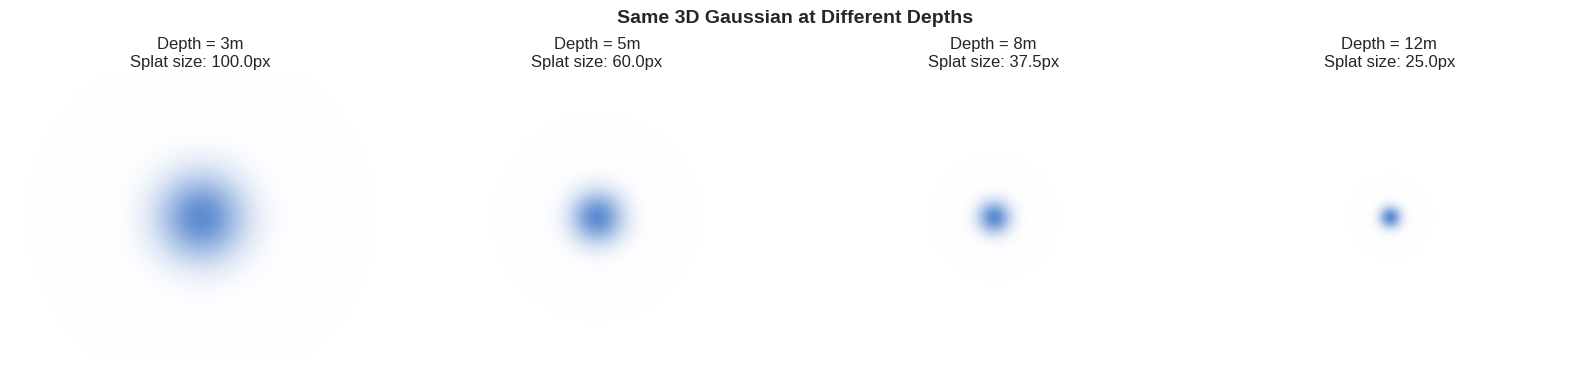


Key Insight:
- Same 3D size → smaller 2D splat when further away
- This is the perspective projection effect
- The Jacobian captures this: J ∝ 1/z


In [23]:
# Same Gaussian at different depths
depths = [3, 5, 8, 12]
same_scaling = torch.tensor([0.3, 0.3, 0.3])
same_rotation = torch.tensor([1., 0., 0., 0.])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, depth in zip(axes, depths):
    g3d = Gaussian3D(
        mean=torch.tensor([0., 0., float(depth)]),
        scaling=same_scaling,
        rotation=same_rotation,
        opacity=0.9,
        color=torch.tensor([0.3, 0.5, 0.8])
    )
    
    cam = Camera(fx=500, fy=500, cx=320, cy=240, width=640, height=480,
                R=torch.eye(3), t=torch.zeros(3))
    
    g2d = project_gaussian_to_2d(g3d, cam)
    img = render_gaussians([g2d], cam)
    
    ax.imshow(img.numpy())
    
    # Compute splat size
    eigenvalues = torch.linalg.eigvalsh(g2d.covariance)
    size = 2 * torch.sqrt(eigenvalues.max()).item()
    
    ax.set_title(f'Depth = {depth}m\nSplat size: {size:.1f}px')
    ax.axis('off')

plt.suptitle('Same 3D Gaussian at Different Depths', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("- Same 3D size → smaller 2D splat when further away")
print("- This is the perspective projection effect")
print("- The Jacobian captures this: J ∝ 1/z")

## 8. Summary: The Splatting Pipeline

### Complete Pipeline

```
3D Gaussian (μ, Σ, α, c)     World Space
         │
         ▼
   μ_cam = R·μ + t           Camera Transform
   Σ_cam = R·Σ·R^T
         │
         ▼
   μ_2d = project(μ_cam)     Perspective Projection
   J = Jacobian(μ_cam)
   Σ_2d = J·Σ_cam·J^T
         │
         ▼
2D Gaussian (μ_2d, Σ_2d, α, c)  Image Space
         │
         ▼
   Evaluate on pixel grid    Rasterization
         │
         ▼
      Rendered Image         Output
```

### Key Formulas

| Operation | Formula |
|-----------|--------|
| World to Camera | $\mathbf{p}_{cam} = R \cdot \mathbf{p} + \mathbf{t}$ |
| Perspective Projection | $u = f_x \cdot x/z + c_x$ |
| Projection Jacobian | $J = \begin{bmatrix} f_x/z & 0 & -f_x x/z^2 \\ 0 & f_y/z & -f_y y/z^2 \end{bmatrix}$ |
| Covariance Projection | $\Sigma_{2D} = J \cdot \Sigma_{cam} \cdot J^T$ |

---

## Key Takeaways

1. **Projection is nonlinear**: We use the Jacobian for local linearization
2. **Depth matters**: Closer Gaussians appear larger (1/z scaling)
3. **Covariance transforms**: Both rotation and projection affect the shape
4. **Complete pipeline**: 3D → Camera → 2D → Image

---

## Next Steps

In the next notebook, we'll learn about **differentiable rendering** and how to compute gradients through the entire pipeline:

**[04_differentiable_rendering.ipynb](./04_differentiable_rendering.ipynb)** - Differentiable Rendering